<a href="https://colab.research.google.com/github/Lanzero225/ClinicScheduleApp/blob/master/ReZearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RE:ZEARCH
A Data-Driven Approach Leveraging extraction-based summarization as a Research Tool and Discovery of Academic Gaps



-----
## Background



Coming up with a novel research idea may be difficult, with new innovations left and right. Undergraduate students have a difficult time with coming up with ideal topics.

Both graduate and undergraduate students have problems in academic writing, organizing ideas, and writing coherently. Some find it difficult to come up with meaningful research questions for their academic works.

### Objectives



The objective of this project is to develop an NLP-powered software that facilitates the discovery of academic gaps and research trends of literature in arXiv using Extraction-Based Summarization for students, researchers, and educators to use as a research tool.

### Dataset



The dataset is a collection of 1.7 million articles from arXiv, an open-source repository of scholarly articles from various fields.

This dataset comprises article titles, authors, categories, abstracts, and the respective PDF documents.

ArXiv is an open repository of research articles operated by Cornell University.

Here is the link to the Kaggle Dataset:
https://www.kaggle.com/datasets/Cornell-University/arxiv

The dataset contains the following fields:
- id: Research paper ID
- submitter
- authors: Authors contatenated into one string
- title
- comments
- journal-ref
- doi
- report-no
- categories: Field of study
- license
- abstract
- versions
- update_date
- authors_parsed

Before we even begin the project, let us import all necessary libraries we need.

In [ ]:
import polars as pl
from pathlib import Path
import pandas as pd
import numpy as np
import h5py
from sentence_transformers import SentenceTransformer
import torch
import faiss
import pyarrow.parquet as pq
from keybert import KeyBERT
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
import umap
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


-----
## Data Preparation



First, let us gather the data. After downloading the dataset from kaggle, I placed it in a directory where all the other files related will be used.

Since the dataset will contain 1.7+ million papers, that means there will be 1.7+ million records. That simply isn't efficient if we're turning that into a DataFrame. I will be using polars, which is a library to make data analysis more efficient through speed and optimal memory use, especially for a dataset this large.

For the purposes of this project, I will only be selecting the ID (For indexing), title, categories, and abstract, as they are the only ones that fit our objective.

After the polars library does its scan, the DataFrame will be saved as a parquet file into our directory.

In [ ]:
current_dir = Path.cwd()

json_path = current_dir / "arxiv-metadata-oai-snapshot.json"
parquet_path = current_dir / "arxiv_data.parquet"
embedding_path = current_dir / "title_embeddings.h5"
faiss_index_path = current_dir / "arxiv_titles.index"

In [ ]:
print("Dataset path:", json_path)

df = (
    pl.scan_ndjson(json_path)
      .select(['id', 'title', 'categories', 'abstract'])
      .collect(streaming=True)
)

parquet_path = current_dir / "arxiv_data.parquet"
df.write_parquet(parquet_path)

print(f"Optimization Complete: Saved to {parquet_path}")

### Converting the Dataset to an HDF5 File (Embeddings Storage)

In this step, we convert our Parquet dataset (arxiv_data.parquet) into an HDF5 file (.h5) containing vector embeddings.

Instead of storing raw text, we will load the titles, convert them into dense vector embeddings using a transformer model, and store those vectors efficiently in an HDF5 file.

This let's us search for similarities faster, let's us use FAISS indexing, and is in general, more efficient and optimal.

The use of HDF5 will also be of help here since it supports large datasets (millions of rows). We can also load everything in chunks, making it more optimal. Lastly, compared to CSV or JSON, it is much smaller, faster, and structured for numerical arrays.

We can check first if we have a GPU available, so that we can run faster. After that, we can define our model as a SentenceTransformer. A Sentence Transformer (SBERT) is a type of transformer based-model that is used for semantic search. By creating 384-dimensional embeddings.

This is an improvement from BERT's limitations. Both are used for semantic analysis, but SBERT analyzes text in sentence level, has a fixed-size embedding, and is best for semantic search, which is useful for our project.

```
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
embedding_size = 384
```



The code below will initialize the parquet DataFrame, then the model. After that, we will begin embedding the H5PY file. We will create a file and allocate space for this. Then, for every chunk with a size of 100,000, we will slowly write the embeddings per 256 samples.

After the iterations, the file will be saved to the embeddings path.

In [ ]:
df = pd.read_parquet(parquet_path, columns=["title"])
titles = df["title"].tolist()
num_titles = len(titles)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
embedding_size = 384

chunk_size = 100000

print(f"Starting embedding for {num_titles} rows...")

with h5py.File(embedding_path, "w") as f:
    dset = f.create_dataset("embeddings", (num_titles, embedding_size), dtype="float32")

    for i in range(0, num_titles, chunk_size):
        end = min(i + chunk_size, num_titles)
        print(f"Processing chunk: {i} to {end}...")

        chunk_embeddings = model.encode(
            titles[i:end],
            batch_size=256,
            show_progress_bar=False,
            convert_to_numpy=True,
        )

        dset[i:end] = chunk_embeddings
        del chunk_embeddings

print(f"Success! Embeddings saved to {embedding_path}")

### Building the FAISS Index from HDF5 Embeddings

This block of code builds a FAISS similarity search index from the embeddings stored in the HDF5 file. After previously converting all titles into 384-dimensional numerical vectors and saving them efficiently, we will then transform those stored embeddings into a structure that enables fast semantic search.

Instead of scanning every vector manually during a query, FAISS organizes the vectors in a way that allows efficient nearest-neighbor retrieval using Euclidean distance. The embeddings are loaded from the HDF5 file in chunks to prevent excessive memory usage. Each chunk of vectors is added to the index incrementally until all embeddings are indexed.

Finally, the completed FAISS index is saved to disk as a .index file, which can later be loaded to perform similarity searches over the entire dataset.

In [ ]:
dimension = 384
index = faiss.IndexFlatL2(dimension)

print("Building FAISS index in chunks...")

with h5py.File(embedding_path, "r") as f:
    dset = f["embeddings"]
    total_rows = dset.shape[0]
    chunk_size = 100000

    for i in range(0, total_rows, chunk_size):
        end = min(i + chunk_size, total_rows)

        chunk = dset[i:end].astype("float32")
        index.add(chunk)

        print(f"Indexed {end} / {total_rows}...")
        del chunk

print(f"Success! Total vectors indexed: {index.ntotal}")

faiss.write_index(index, str(faiss_index_path))

print(f"FAISS index saved to {faiss_index_path}")

-----
## Model Creation



In this next step, we will begin the creation of the system itself.

The first function, read_parquet_rows, is designed to efficiently retrieve specific rows from the parquet file without loading the entire dataset into memory. Since the FAISS index only returns vector positions (row indices), this function maps those indices back to the original dataset.

It determines which row group a requested index belongs to, reads only from that row group, and extracts the exact row needed. This lookup approach keeps memory usage low.

In [ ]:
def read_parquet_rows(parquet_path, row_indices, columns=None):
    pq_file = pq.ParquetFile(parquet_path)
    rows = []
    for i in row_indices:
        row_group = i // pq_file.metadata.row_group(0).num_rows
        row_in_group = i % pq_file.metadata.row_group(0).num_rows
        table = pq_file.read_row_group(row_group, columns=columns)
        rows.append(table.to_pandas().iloc[row_in_group])
    return pd.DataFrame(rows)

The second function, rezearch_query_safe, performs the actual semantic search. It takes a proposal title as input and converts it into a vector embedding using the same transformer model that was used to embed the dataset.

It then queries the FAISS index to retrieve the top k (5 by default) most similar embeddings based on L2 distance. The returned indices correspond to rows in the original dataset, so the function calls read_parquet_rows to fetch the titles, categories, and abstracts of the matching papers.

It also returns a “gap score,” which represents the distance between the query and the closest match—this can be interpreted as how semantically similar the proposal is to existing research.

In [ ]:
def rezearch_query_safe(proposal_title, k=5):
    query_vec = model.encode([proposal_title])

    distances, indices = index.search(query_vec.astype('float32'), k)

    hit_rows = indices[0].tolist()
    metadata = read_parquet_rows(parquet_path, hit_rows, columns=['title','categories','abstract'])

    gap_score = distances[0][0]

    return metadata, gap_score

The third block uses LexRank for extractive summarization. The summarize_and_extract_keywords function takes a research abstract and generates a concise summary. It doesn't generate text, rather identifies the most central sentences based on graph-based ranking, making it computationally efficient and suitable for research abstracts.

After that, it uses KeyBERT, using  transformer embeddings to identify the most semantically meaningful keywords and keyphrases in a document. This returns a  condensed explanation of the research and its main terms, making it easier to understand the focus of the retrieved paper.

In [ ]:
kw_model = KeyBERT(model='all-MiniLM-L6-v2')

def summarize_and_extract_keywords(text, sentences_count=2, top_keywords=5):
    parser = PlaintextParser.from_string(text, Tokenizer("english"))
    summarizer = LexRankSummarizer()
    summary = summarizer(parser.document, sentences_count)
    summary_text = " ".join([str(sentence) for sentence in summary])

    keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=(1,2), stop_words='english', top_n=top_keywords)
    keywords = [kw[0] for kw in keywords]

    return summary_text, keywords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Lastly, we can proceed to building them all together.

The function research_dashboard takes in a proposal title and uses the previous function to return top research papers, their summarized abstract, and the relevant keywords.

In [ ]:

def research_dashboard(proposal_title, k=5):
    results, gap_score = rezearch_query_safe(proposal_title, k)

    dashboard_rows = []
    for idx, row in results.iterrows():
        summary, keywords = summarize_and_extract_keywords(row['abstract'])
        dashboard_rows.append({
            'Title': row['title'],
            'Categories': row['categories'],
            'Summary': summary,
            'Keywords': ", ".join(keywords)
        })

    dashboard_df = pd.DataFrame(dashboard_rows)
    return dashboard_df, gap_score

dashboard_df, gap_score = research_dashboard("Quantum Machine Learning for Climate Prediction", k=5)
print(f"Gap Score: {gap_score}")
dashboard_df

Gap Score: 0.052598193287849426


,Title,Categories,Summary,Keywords
0,Quantum Machine Learning for Climate Modelling,quant-ph physics.ao-ph,Quantum machine learning (QML) is making rapid...,"models qnn, quantum neural, predict cloud, qnn..."
1,Exploring Quantum Machine Learning for Weather...,quant-ph cs.LG,Weather forecasting plays a crucial role in su...,"quantum computing, quantum neural, quantum mac..."
2,Quantum Machine Learning in Climate Change and...,cs.LG cs.AI,Climate change and its impact on global sustai...,"quantum computing, quantum machine, learning q..."
3,Quantum-Assisted Machine Learning Models for E...,quant-ph cs.ET cs.LG,Quantum Machine Learning (QML) presents as a r...,"quantum computing, qml weather, quantum machin..."
4,Potential of quantum scientific machine learni...,quant-ph,In this work we explore how quantum scientific...,"explore quantum, quantum scientific, quantum a..."


To better visualize the gap score, the function visualize_top_papers takes in the prompt used and looks into the top indices to see the relevant rows closest to it, mapping the top similar maps in a scallter plot.

In [ ]:
def visualize_top_papers(indices):
    import h5py
    with h5py.File(embedding_path, 'r') as f:
      all_emb = f['embeddings']
      indices_np = np.array(indices)
      emb = np.vstack([all_emb[i] for i in indices_np])

    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='cosine')
    embeddings_2d = reducer.fit_transform(emb)

    plt.figure(figsize=(8,6))
    plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])
    for i, idx in enumerate(indices):
        plt.text(embeddings_2d[i,0], embeddings_2d[i,1], str(i+1), fontsize=9)
    plt.title("Top Paper Similarity Map")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


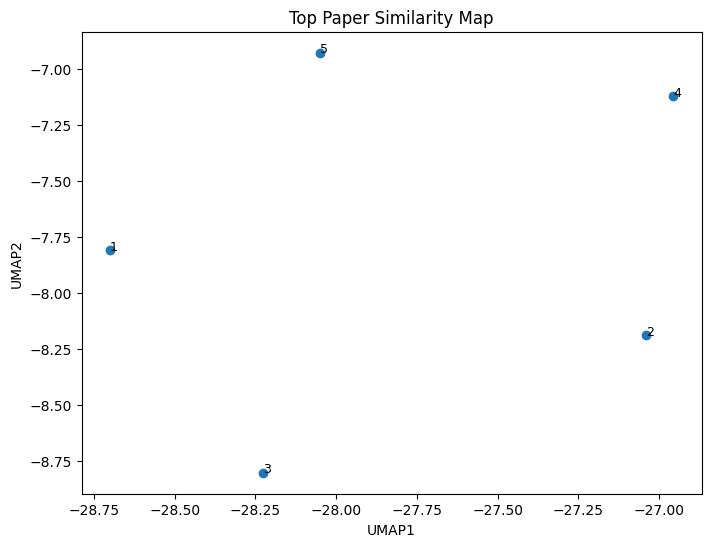

In [ ]:
_, top_indices = index.search(model.encode(["Quantum Machine Learning for Climate Prediction"]).astype('float32'), 5)
visualize_top_papers(top_indices[0])

### Interactive System



Now that everything is all set, we can then try to implement a way to allow users to test the system, but for now, we will use a notebook. Let us first instantiate all the necessary variables.

In [ ]:
dimension = 384
index = faiss.read_index(faiss_index_path)

device = "cpu"
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

kw_model = KeyBERT(model=model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Next, we can define the code, creating a widget in our notebook. Essentially, this will create a textbox where we can enter our prompt, and when we click the button, the system will run, taking the top matching papers to our prompt, and return those papers as well as the other necessary information.

In [ ]:
input_box = widgets.Text(
    value='Quantum Machine Learning for Climate Prediction',
    placeholder='Type your proposal title here',
    description='Proposal:',
    layout=widgets.Layout(width='80%')
)

button = widgets.Button(description="Search Papers")
output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        dashboard_df, gap_score = research_dashboard(input_box.value, k=5)
        print(f"Gap Score: {gap_score}")
        display(dashboard_df)

button.on_click(on_button_click)
display(input_box, button, output)

Text(value='Quantum Machine Learning for Climate Prediction', description='Proposal:', layout=Layout(width='80…

Button(description='Search Papers', style=ButtonStyle())

Output()

-----
## Conclusion



In this notebook, we developed a complete semantic research retrieval system powered by transformer embeddings and FAISS similarity search. Starting from raw arXiv metadata, we converted textual data into dense vector representations, stored them efficiently in HDF5 format, and indexed them for fast nearest-neighbor search. We then implemented a retrieval pipeline that:

- Embeds a user-provided research proposal
- Searches for the most semantically similar papers
- Retrieves relevant metadata from the dataset
- Summarizes abstracts for quick interpretation
- Extracts key thematic keywords
- Displays results interactively using a notebook widget

This project can provide assistance for:
- Literature review automation
- Proposal novelty checking
- Semantic document retrieval
- Academic recommendation systems

-----
## Recommendation



There are still a lot to improve upon this first version of ReZearch. We can look into switching to other indexing approaches other than IndexFlatL2 such as IndexIVFFlat or HNSW, but those require better CPU and memory. We can also add cosine similarity, since gap distance also uses L2.

In terms of the semantic search itself, we can add a hybrid search, combining keywords and semantics, as well as adding a scoring system to determine accuracy. Research integrity can also be an addition, where we can integrate rankings of the research papers retrieved based on their peer review status.

Lastly, the system itself is very memory intensive, but implementing a web application is not out of the table.

Overall,

This project served as a mini mini thesis to one of our initial title proposals that we didn't choose to continue. It combines contemporary NLP techniques with efficient vector indexing to build a semantic search systems.

The pipeline is modular and extensible, though resource extensive. The original dataset has been updated from an initial 1.7 million to a whopping 2.9 million. If the system were to be updated, it would require an estimated 1-2 hours, 10 gb of storage, and a better memory and cpu.